In [1]:
# repo setup / imports

import os
import subprocess
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score
)
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"], check=False)
    else:
        subprocess.run(["git", "clone", REPO_URL], check=False)

clone_or_pull()

DATA_DIR = os.path.join(REPO_DIR, "Data")
STOCKS_CSV = os.path.join(DATA_DIR, "nlp_clean_stock_symbols.csv")
ZIP_PATH = os.path.join(DATA_DIR, "final_dataset_20260224v2.csv.zip")
CSV_IN_ZIP = "final_dataset_20260224v2.csv"

Already up to date.


In [2]:
# load_stocks

def load_stocks(path=STOCKS_CSV):
    df = pd.read_csv(path)

    required_cols = ["symbol", "document_clean_tfidf", "document_raw"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in stock NLP file: {missing}")

    # keyword text: cleaner TF-IDF-oriented text
    df["kw_text"] = df["document_clean_tfidf"].fillna(df["document_raw"]).fillna("")

    # semantic text: raw text preferred for embeddings
    df["sem_text"] = df["document_raw"].fillna(df["document_clean_tfidf"]).fillna("")

    # keep only rows with at least some usable text
    df = df[
        (df["kw_text"].astype(str).str.len() > 0) |
        (df["sem_text"].astype(str).str.len() > 0)
    ].copy()

    df["symbol"] = df["symbol"].astype(str).str.upper().str.strip()
    df["kw_text"] = df["kw_text"].astype(str)
    df["sem_text"] = df["sem_text"].astype(str)

    return df.reset_index(drop=True)

df_stocks = load_stocks(STOCKS_CSV)
print("Loaded stock NLP rows:", df_stocks.shape)
print(df_stocks[["symbol", "kw_text", "sem_text"]].head(3))

Loaded stock NLP rows: (10283, 8)
  symbol                                            kw_text  \
0   NVDA  nvidia corp technology semiconductors nvidia c...   
1  GOOGL  alphabet communication services internet conte...   
2   AAPL  apple technology consumer electronics apple de...   

                                            sem_text  
0  NVIDIA CORP Technology Semiconductors NVIDIA C...  
1  Alphabet Inc. Communication Services Internet ...  
2  Apple Inc. Technology Consumer Electronics App...  


In [3]:
# load final zipped dataset

with zipfile.ZipFile(ZIP_PATH) as z:
    df = pd.read_csv(z.open(CSV_IN_ZIP))

print("Main dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

if "Ticker" not in df.columns or "Date" not in df.columns or "fwd_excess" not in df.columns:
    raise ValueError("Expected columns Ticker, Date, and fwd_excess were not found.")

df["Ticker"] = df["Ticker"].astype(str).str.upper().str.strip()
df["Date"] = pd.to_datetime(df["Date"])

print("Unique tickers:", df["Ticker"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Main dataset shape: (302024, 18)
Columns:
['Date', 'Ticker', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m', 'mom_12m_ex_1m', 'rel_3m_spy', 'rel_6m_spy', 'rel_12m_spy', 'vol_3m', 'vol_6m', 'drawdown_6m', 'drawdown_12m', 'pct_above_200dma', 'adj_close', 'fwd_excess', 'fwd_return']
Unique tickers: 1993
Date range: 2010-02-28 00:00:00 to 2026-02-28 00:00:00


In [4]:
# create y

df = df.copy()
df["y"] = (df["fwd_excess"] > 0).astype(int)

print("Number of positive fwd_excess:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess:", (df["fwd_excess"] == 0).sum())
print("Target distribution:")
print(df["y"].value_counts(normalize=True).sort_index())

Number of positive fwd_excess: 143948
Number of negative fwd_excess: 151730
Number of zero fwd_excess: 287
Target distribution:
y
0    0.523389
1    0.476611
Name: proportion, dtype: float64


In [5]:
# create df_rank

rank_cols = [
    "mom_1m", "mom_3m", "mom_6m", "mom_12m", "mom_12m_ex_1m",
    "rel_3m_spy", "rel_6m_spy", "rel_12m_spy",
    "vol_3m", "vol_6m",
    "drawdown_6m", "drawdown_12m",
    "pct_above_200dma"
]

required_for_model = ["Date", "Ticker", "fwd_excess", "y", "adj_close"] + rank_cols
missing_required = [c for c in required_for_model if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for ranking/modeling: {missing_required}")

# drop rows missing model-critical columns
df_model_base = df.dropna(subset=required_for_model).copy()

df_rank = df_model_base.copy()

for col in rank_cols:
    df_rank[col] = df_rank.groupby("Date")[col].rank(pct=True)

df_rank["fwd_rank"] = df_rank.groupby("Date")["fwd_excess"].rank(pct=True)

df_rank["target"] = pd.cut(
    df_rank["fwd_rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[0, 1, 2, 3, 4],
    include_lowest=True
)

print("df_rank shape:", df_rank.shape)
print(df_rank.head(3))

df_rank shape: (274511, 21)
            Date Ticker    mom_1m    mom_3m    mom_6m   mom_12m  \
13389 2011-01-31   NVDA  0.997496  0.995826  0.995826  0.814691   
13390 2011-01-31  GOOGL  0.480801  0.142738  0.636060  0.281302   
13391 2011-01-31   AAPL  0.729549  0.623539  0.766277  0.909015   

       mom_12m_ex_1m  rel_3m_spy  rel_6m_spy  rel_12m_spy  ...    vol_6m  \
13389       0.137730    0.995826    0.995826     0.814691  ...  0.928214   
13390       0.276294    0.142738    0.636060     0.281302  ...  0.438230   
13391       0.889816    0.623539    0.766277     0.909015  ...  0.222871   

       drawdown_6m  drawdown_12m  pct_above_200dma  adj_close  fwd_excess  \
13389     0.744157      0.790067          0.995826     0.5483     -0.2287   
13390     0.377295      0.476628          0.515025    14.9114     -0.1585   
13391     0.744157      0.790067          0.747913    10.1670     -0.0330   

       fwd_return  y  fwd_rank  target  
13389     -0.1639  0  0.030050       0  
13390  

In [6]:
# helper functions

def retrieve_features(df):
    drop_cols = [
        "Date", "Ticker",
        "fwd_excess", "fwd_return", "y", "fwd_rank", "target",
        "kw_text", "sem_text"
    ]
    feature_cols = [col for col in df.columns if col not in drop_cols]
    feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    return feature_cols


def time_split(
    df,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    sort_dates=True
):
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("train_frac + val_frac + test_frac must equal 1.0")

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    if sort_dates:
        data = data.sort_values(date_col)

    unique_dates = (
        pd.Series(data[date_col].drop_duplicates())
        .sort_values()
        .reset_index(drop=True)
    )

    n_dates = len(unique_dates)
    train_end = int(n_dates * train_frac)
    val_end = int(n_dates * (train_frac + val_frac))

    train_dates = unique_dates.iloc[:train_end]
    val_dates = unique_dates.iloc[train_end:val_end]
    test_dates = unique_dates.iloc[val_end:]

    train_df = data[data[date_col].isin(train_dates)].copy()
    val_df = data[data[date_col].isin(val_dates)].copy()
    test_df = data[data[date_col].isin(test_dates)].copy()

    return train_df, val_df, test_df


def create_confusion_matrix(model, X, y, name):
    y_pred = model.predict(X)
    cm = confusion_matrix(y, y_pred)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    print(f"\n{name}")
    print(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return cm_df

In [7]:
# connecting NLP outputs to LightGBM inputs

# Merge text onto modeling dataset
text_df = (
    df_stocks[["symbol", "kw_text", "sem_text"]]
    .drop_duplicates(subset=["symbol"])
    .rename(columns={"symbol": "Ticker"})
    .copy()
)

text_df["Ticker"] = text_df["Ticker"].astype(str).str.upper().str.strip()

df_model = df_rank.copy()
df_model["Ticker"] = df_model["Ticker"].astype(str).str.upper().str.strip()

df_model = df_model.merge(text_df, on="Ticker", how="left")
df_model["kw_text"] = df_model["kw_text"].fillna("")
df_model["sem_text"] = df_model["sem_text"].fillna("")

print("Merged model shape:", df_model.shape)
print("Share with kw_text:", (df_model["kw_text"].str.len() > 0).mean())
print("Share with sem_text:", (df_model["sem_text"].str.len() > 0).mean())

# Time split
train_df, val_df, test_df = time_split(
    df_model,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15
)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Numeric features
numeric_cols = retrieve_features(train_df)

X_train_num = train_df[numeric_cols].reset_index(drop=True)
X_val_num = val_df[numeric_cols].reset_index(drop=True)
X_test_num = test_df[numeric_cols].reset_index(drop=True)

y_train = train_df["y"].reset_index(drop=True)
y_val = val_df["y"].reset_index(drop=True)
y_test = test_df["y"].reset_index(drop=True)

print("Numeric feature count:", len(numeric_cols))

# TF-IDF features fit on train only
tfidf = TfidfVectorizer(
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(train_df["kw_text"].astype(str))
X_val_tfidf = tfidf.transform(val_df["kw_text"].astype(str))
X_test_tfidf = tfidf.transform(test_df["kw_text"].astype(str))

svd_n = min(50, max(2, X_train_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=svd_n, random_state=42)

X_train_tfidf_svd = svd.fit_transform(X_train_tfidf)
X_val_tfidf_svd = svd.transform(X_val_tfidf)
X_test_tfidf_svd = svd.transform(X_test_tfidf)

tfidf_cols = [f"tfidf_svd_{i}" for i in range(X_train_tfidf_svd.shape[1])]

X_train_tfidf_df = pd.DataFrame(X_train_tfidf_svd, columns=tfidf_cols)
X_val_tfidf_df = pd.DataFrame(X_val_tfidf_svd, columns=tfidf_cols)
X_test_tfidf_df = pd.DataFrame(X_test_tfidf_svd, columns=tfidf_cols)

print("TF-IDF vocab size:", len(tfidf.vocabulary_))
print("TF-IDF reduced feature count:", len(tfidf_cols))

# SBERT embeddings with deduplicated encoding
def encode_unique_texts(text_series, model, batch_size=128):
    text_series = pd.Series(text_series).fillna("").astype(str)
    unique_texts = pd.Index(text_series.unique())
    unique_emb = model.encode(
        unique_texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)
    emb_lookup = {txt: emb for txt, emb in zip(unique_texts.tolist(), unique_emb)}
    return np.vstack(text_series.map(emb_lookup).values)

sbert_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

E_train = encode_unique_texts(train_df["sem_text"], sbert_model, batch_size=128)
E_val = encode_unique_texts(val_df["sem_text"], sbert_model, batch_size=128)
E_test = encode_unique_texts(test_df["sem_text"], sbert_model, batch_size=128)

print("Raw SBERT dimension:", E_train.shape[1])

pca_n = min(32, E_train.shape[1], E_train.shape[0])
pca = PCA(n_components=pca_n, random_state=42)

E_train_red = pca.fit_transform(E_train)
E_val_red = pca.transform(E_val)
E_test_red = pca.transform(E_test)

emb_cols = [f"sbert_{i}" for i in range(E_train_red.shape[1])]

X_train_emb_df = pd.DataFrame(E_train_red, columns=emb_cols)
X_val_emb_df = pd.DataFrame(E_val_red, columns=emb_cols)
X_test_emb_df = pd.DataFrame(E_test_red, columns=emb_cols)

print("SBERT reduced feature count:", len(emb_cols))

# Combine all features
X_train_all = pd.concat([X_train_num, X_train_tfidf_df, X_train_emb_df], axis=1)
X_val_all = pd.concat([X_val_num, X_val_tfidf_df, X_val_emb_df], axis=1)
X_test_all = pd.concat([X_test_num, X_test_tfidf_df, X_test_emb_df], axis=1)

# LightGBM likes clean string column names
X_train_all.columns = X_train_all.columns.astype(str)
X_val_all.columns = X_val_all.columns.astype(str)
X_test_all.columns = X_test_all.columns.astype(str)

print("Final X_train shape:", X_train_all.shape)
print("Final X_val shape:", X_val_all.shape)
print("Final X_test shape:", X_test_all.shape)

# Train LightGBM
lgb_model_nlp = lgb.LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

lgb_model_nlp.fit(
    X_train_all,
    y_train,
    eval_set=[(X_val_all, y_val)],
    eval_metric="binary_logloss",
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100)
    ]
)

Merged model shape: (274511, 23)
Share with kw_text: 1.0
Share with sem_text: 1.0
Train shape: (176701, 23)
Val shape: (47488, 23)
Test shape: (50322, 23)
Numeric feature count: 14


TF-IDF vocab size: 10000
TF-IDF reduced feature count: 50


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Raw SBERT dimension: 384
SBERT reduced feature count: 32
Final X_train shape: (176701, 96)
Final X_val shape: (47488, 96)
Final X_test shape: (50322, 96)
[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119357 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24480
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.698067
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.693263


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.03
,n_estimators,2000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



VALIDATION RESULTS

Validation: Ranked + TFIDF + SBERT
          Pred 0  Pred 1
Actual 0    7993   16837
Actual 1    7943   14715


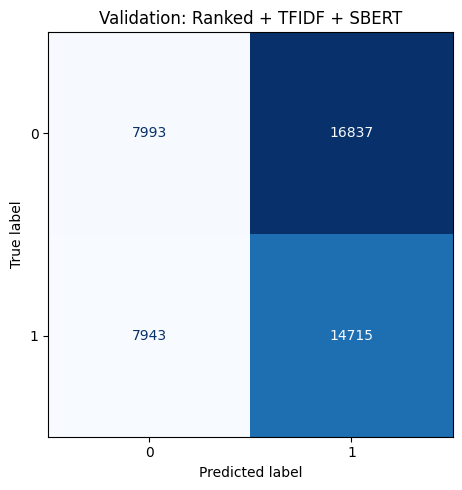

Validation Accuracy: 0.47818396226415094
Validation ROC-AUC: 0.4776106689581306

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.32      0.39     24830
           1       0.47      0.65      0.54     22658

    accuracy                           0.48     47488
   macro avg       0.48      0.49      0.47     47488
weighted avg       0.48      0.48      0.46     47488


TEST RESULTS

Test: Ranked + TFIDF + SBERT
          Pred 0  Pred 1
Actual 0    8562   18199
Actual 1    8328   15233


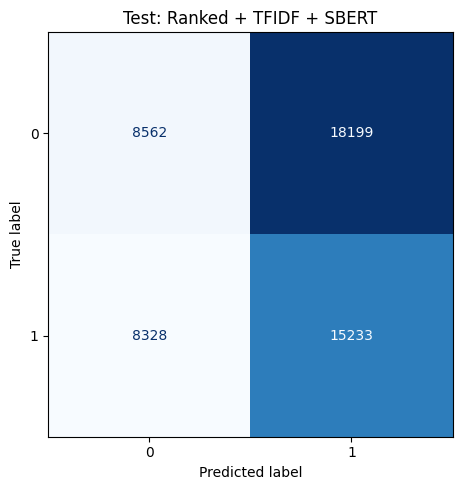

Test Accuracy: 0.47285481499145504
Test ROC-AUC: 0.48531399494985955

Test Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.32      0.39     26761
           1       0.46      0.65      0.53     23561

    accuracy                           0.47     50322
   macro avg       0.48      0.48      0.46     50322
weighted avg       0.48      0.47      0.46     50322


Top 25 features:
             feature  importance
0          adj_close           5
1       tfidf_svd_33           2
2       tfidf_svd_29           2
3       tfidf_svd_19           2
4        tfidf_svd_7           1
5       tfidf_svd_17           1
6       tfidf_svd_15           1
7        tfidf_svd_8           1
8       tfidf_svd_10           1
9        tfidf_svd_2           1
10      tfidf_svd_28           1
11      tfidf_svd_26           1
12      tfidf_svd_20           1
13       tfidf_svd_4           1
14       tfidf_svd_3           1
15      tfidf_svd_14         

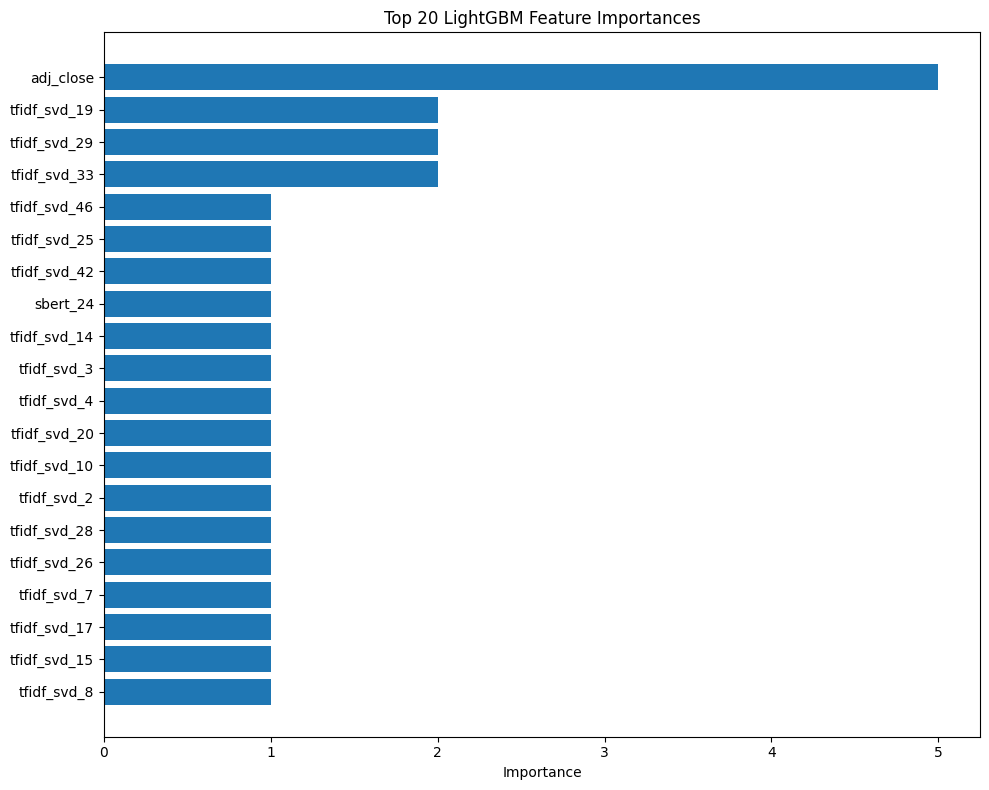

In [8]:
# evaluate results

# Validation
print("\nVALIDATION RESULTS")
create_confusion_matrix(lgb_model_nlp, X_val_all, y_val, "Validation: Ranked + TFIDF + SBERT")

val_pred = lgb_model_nlp.predict(X_val_all)
val_prob = lgb_model_nlp.predict_proba(X_val_all)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, val_prob))
print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred, zero_division=0))

# Test
print("\nTEST RESULTS")
create_confusion_matrix(lgb_model_nlp, X_test_all, y_test, "Test: Ranked + TFIDF + SBERT")

test_pred = lgb_model_nlp.predict(X_test_all)
test_prob = lgb_model_nlp.predict_proba(X_test_all)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_prob))
print("\nTest Classification Report:")
print(classification_report(y_test, test_pred, zero_division=0))

# Feature importance
feature_importance = pd.DataFrame({
    "feature": X_train_all.columns,
    "importance": lgb_model_nlp.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 25 features:")
print(feature_importance.head(25))

plt.figure(figsize=(10, 8))
top_n = 20
plot_df = feature_importance.head(top_n).sort_values("importance", ascending=True)
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()